# Notebook de dev pour l'entrainement vers MLflow

In [5]:
import logging
import numpy as np

import os
import mlflow
from mlflow import log_metric, log_param, log_artifacts
from random import random, randint
from datetime import datetime
import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import time

import pandas as pd
import numpy as np

import boto3


from dotenv import load_dotenv
load_dotenv(override=True)


True

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [7]:
pip install s3fs fsspec

Note: you may need to restart the kernel to use updated packages.


In [8]:

# MLFLOW_TRACKING_URI = os.environ["MLFLOW_TRACKING_URI"]

In [9]:
# MLFLOW_TRACKING_URI

In [10]:


import mlflow

# On pointe vers le serveur distant
remote_server_uri = "https://patjedhahf-mlflow-ppml.hf.space/"
mlflow.set_tracking_uri(remote_server_uri)

# On définit l'expérience
mlflow.set_experiment("ppml-retards-avion")

#     # Log a metric; metrics can be updated throughout the run
#     log_metric("foo", random())
#     log_metric("foo", random() + 1)
#     log_metric("foo", random() + 2)

#     # Log an artifact (output file)
#     if not os.path.exists("outputs"):
#         os.makedirs("outputs")
#     with open("outputs/test.txt", "w") as f:
#         f.write("hello world!")
#     log_artifacts("outputs")


<Experiment: artifact_location='mlflow-artifacts:/789482705024277871', creation_time=1775769560891, experiment_id='789482705024277871', last_update_time=1775769560891, lifecycle_stage='active', name='ppml-retards-avion', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

# 1. Chargement des données

### Option 1. Via SQL

### Option 2. Via CSV

In [11]:
# On va lire un fichier depuis S3
def get_s3_parquet(s3_key):
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1",
    )
    #print(os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"))
    bucket = os.getenv("BUCKET_EQUIPE")
    df= pd.read_parquet(f's3://{bucket}/{s3_key}')   
    return df



In [12]:
df_ppml = get_s3_parquet("prod/train/full_training_2025-10-05_to_2026-04-06.parquet")

df_ppml.columns

Index(['date', 'icao', 'type', 'flight_number', 'call_sign', 'status',
       'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc',
       'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr',
       'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata',
       'destination_name', 'airline_name', 'airline_iata', 'airline_icao',
       'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep',
       'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody',
       'is_narrowbody', 'is_regional', 'aircraft_size_category',
       'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve',
       'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday',
       'holiday_name', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation',
       'cloud_cover'],
      dtype='object')

# colonnes aerodatabox 
'date', 'icao', 'type', 'flight_number', 'call_sign', 'status',
       'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc',
       'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr',
       'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata',
       'destination_name', 'airline_name', 'airline_iata', 'airline_icao',
       'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep',
       'quality_arr', 
# colonnes features appareil :
'aircraft_family', 'num_seats', 'is_widebody',
       'is_narrowbody', 'is_regional', 'aircraft_size_category',
       'is_freighter'
# colonnes feature ferié(librairie python holiday)
'is_holiday', 'is_holiday_eve', 'is_holiday_next',
       'is_weekend', 'is_weekend_or_holiday', 'holiday_name', 'temperature_2m',
       'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m',
       'pressure_msl', 'precipitation', 'cloud_cover'
# TODO VACANCES SCOLAIRES ! 

In [13]:

df_predict = get_s3_parquet("prod/predict/prediction_avril2026.parquet")

df_predict.columns

Index(['date', 'icao', 'type', 'flight_number', 'call_sign', 'status',
       'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc',
       'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr',
       'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata',
       'destination_name', 'airline_name', 'airline_iata', 'airline_icao',
       'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep',
       'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody',
       'is_narrowbody', 'is_regional', 'aircraft_size_category',
       'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve',
       'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday',
       'holiday_name', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation',
       'cloud_cover'],
      dtype='object')

In [14]:
# 1. Préparation de l'heure et des tranches
date_col = 'scheduled_utc' if 'scheduled_utc' in df_ppml.columns else 'date'
df_ppml[date_col] = pd.to_datetime(df_ppml[date_col])
df_ppml['scheduled_hour'] = df_ppml[date_col].dt.hour

def format_tranche(h):
    debut = (h // 2) * 2
    fin = debut + 2
    return f"{debut:02d}h-{fin:02d}h"

df_ppml['tranche_2h'] = df_ppml['scheduled_hour'].apply(format_tranche)

# 2. Calcul, Arrondi et Tri
# On utilise .round(2) pour limiter les décimales
analyse_tranches = df_ppml.groupby('tranche_2h')['delay_minutes'].mean().round(2).reset_index()

# Tri chronologique
analyse_tranches['ordre'] = analyse_tranches['tranche_2h'].str[:2].astype(int)
analyse_tranches = analyse_tranches.sort_values('ordre').drop(columns='ordre')

print("--- Retard moyen par tranche de 2 heures (arrondi) ---")
print(analyse_tranches.to_string(index=False))

--- Retard moyen par tranche de 2 heures (arrondi) ---
tranche_2h  delay_minutes
   00h-02h           2.35
   02h-04h           1.22
   04h-06h           7.12
   06h-08h          11.62
   08h-10h          22.83
   10h-12h          12.40
   12h-14h          20.02
   14h-16h          19.71
   16h-18h          15.76
   18h-20h          13.13
   20h-22h          14.76
   22h-24h           7.85


In [15]:
# Calcul des statistiques globales arrondies à 2 chiffres après la virgule
stats_globales = df_ppml['delay_minutes'].agg(['min', 'mean', 'max', 'median']).round(2)

print("--- Statistiques générales des retards (en minutes) ---")
print(stats_globales)

--- Statistiques générales des retards (en minutes) ---
min       -695.00
mean        15.81
max       1233.00
median      12.00
Name: delay_minutes, dtype: float64


In [16]:
# Statistiques détaillées par tranche de 2h
stats_par_tranche = df_ppml.groupby('tranche_2h')['delay_minutes'].agg(['min', 'mean', 'max', 'median']).round(2)

# Tri pour l'affichage
stats_par_tranche['ordre'] = stats_par_tranche.index.str[:2].astype(int)
stats_par_tranche = stats_par_tranche.sort_values('ordre').drop(columns='ordre')

print("--- Statistiques détaillées par tranches horaires ---")
print(stats_par_tranche)

--- Statistiques détaillées par tranches horaires ---
              min   mean     max  median
tranche_2h                              
00h-02h     -25.0   2.35    79.0     0.0
02h-04h     -73.0   1.22   241.0     0.0
04h-06h    -553.0   7.12   644.0     2.0
06h-08h     -95.0  11.62  1070.0     8.0
08h-10h    -695.0  22.83   758.0    19.0
10h-12h    -101.0  12.40   914.0     7.0
12h-14h     -99.0  20.02   533.0    15.0
14h-16h    -307.0  19.71  1233.0    15.0
16h-18h    -166.0  15.76   543.0    10.0
18h-20h    -120.0  13.13   698.0     8.0
20h-22h    -104.0  14.76   279.0    13.0
22h-24h     -51.0   7.85   143.0     1.0


In [17]:
# 1. Définition de la liste des codes ICAO et de leur nom pour l'affichage
aeroports_cibles = {
    'LFPG': 'Roissy-CDG',
    'LFPO': 'Orly',
    'LFML': 'Marseille',
    'LFMN': 'Nice',
    'LFLL': 'Lyon'
}

# 2. Filtrage du dataset
# On utilise la colonne 'icao' (ou 'destination_icao' selon ton besoin)
df_filtre = df_ppml[df_ppml['icao'].isin(aeroports_cibles.keys())].copy()

# 3. Calcul des statistiques
stats_aeroports = df_filtre.groupby('icao')['delay_minutes'].agg(['min', 'mean', 'max', 'median']).round(2)

# 4. Remplacement des codes par les noms pour plus de clarté
stats_aeroports.index = stats_aeroports.index.map(aeroports_cibles)

print("--- Statistiques des retards par aéroport (en minutes) ---")
print(stats_aeroports.sort_values('mean', ascending=False))

--- Statistiques des retards par aéroport (en minutes) ---
              min   mean     max  median
icao                                    
Roissy-CDG -695.0  16.70  1070.0    13.0
Nice        -59.0  15.53   331.0    13.0
Marseille   -55.0  11.80   279.0     9.0
Orly       -166.0  11.80  1233.0     7.0
Lyon       -120.0   8.13   404.0     0.0


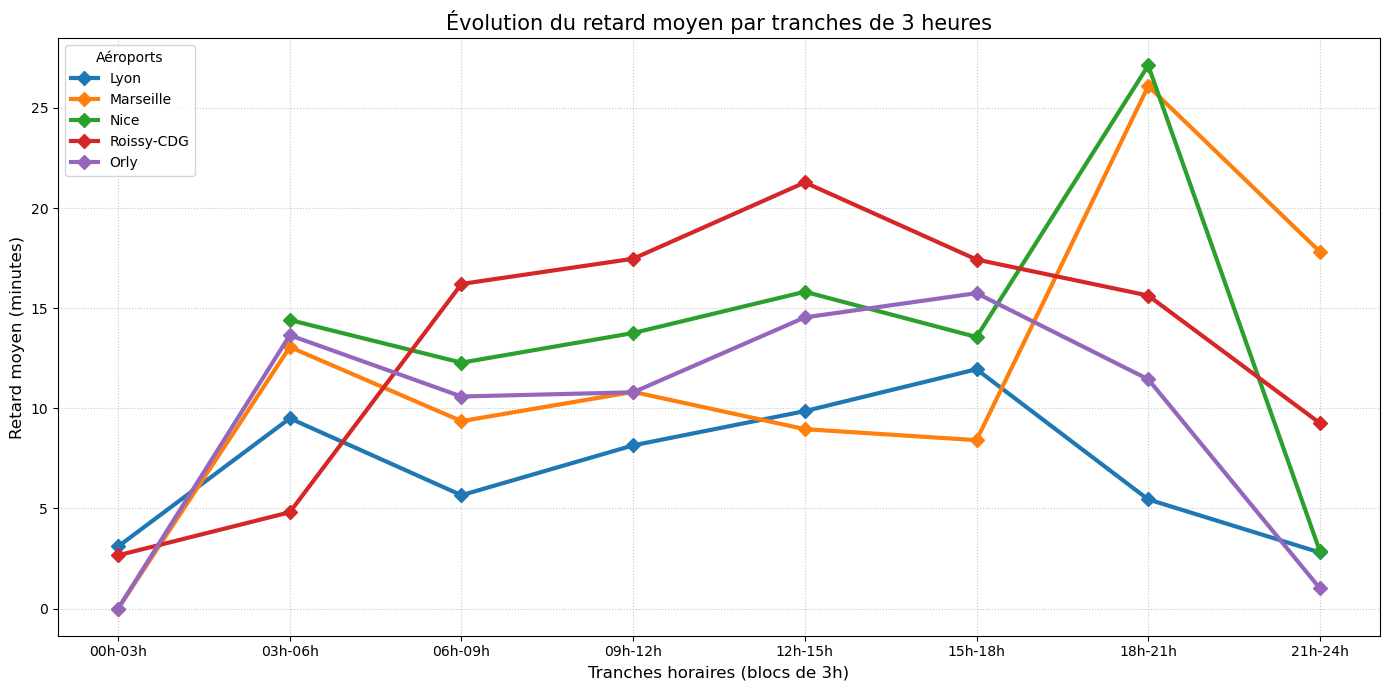

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration des aéroports
aeroports_cibles = {
    'LFPG': 'Roissy-CDG', 
    'LFPO': 'Orly', 
    'LFML': 'Marseille', 
    'LFMN': 'Nice', 
    'LFLL': 'Lyon'
}

# 2. Préparation des tranches de 3h
date_col = 'scheduled_utc' if 'scheduled_utc' in df_ppml.columns else 'date'
df_ppml[date_col] = pd.to_datetime(df_ppml[date_col])
df_ppml['scheduled_hour'] = df_ppml[date_col].dt.hour

def format_tranche_3h(h):
    debut = (h // 3) * 3
    fin = debut + 3
    return f"{debut:02d}h-{fin:02d}h"

df_ppml['tranche_3h'] = df_ppml['scheduled_hour'].apply(format_tranche_3h)

# 3. Filtrage et Pivot
df_filtre = df_ppml[df_ppml['icao'].isin(aeroports_cibles.keys())].copy()
comparaison_3h = df_filtre.pivot_table(
    values='delay_minutes', 
    index='tranche_3h', 
    columns='icao', 
    aggfunc='mean'
).round(2)

# Tri chronologique et renommage
comparaison_3h.columns = comparaison_3h.columns.map(aeroports_cibles)

# 4. Création du visuel
plt.figure(figsize=(14, 7))

for aeroport in comparaison_3h.columns:
    plt.plot(
        comparaison_3h.index, 
        comparaison_3h[aeroport], 
        marker='D',          # Marqueur en forme de diamant
        label=aeroport, 
        linewidth=3,
        markersize=7
    )

plt.title("Évolution du retard moyen par tranches de 3 heures", fontsize=15)
plt.xlabel("Tranches horaires (blocs de 3h)", fontsize=12)
plt.ylabel("Retard moyen (minutes)", fontsize=12)
plt.legend(title="Aéroports", loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Affichage
plt.show()

In [19]:
# 1. Définition des codes ICAO
aeroports_cibles = {
    'LFPG': 'Roissy-CDG',
    'LFPO': 'Orly',
    'LFML': 'Marseille',
    'LFMN': 'Nice',
    'LFLL': 'Lyon'
}

# 2. Filtrage et comptage
# On utilise 'icao' pour identifier l'aéroport du dataset
comptage = df_ppml[df_ppml['icao'].isin(aeroports_cibles.keys())]['icao'].value_counts()

# 3. Affichage propre
print("--- Nombre de vols par aéroport ---")
for code, nom in aeroports_cibles.items():
    nb_vols = comptage.get(code, 0)
    print(f"{nom} ({code}) : {nb_vols:,} vols".replace(',', ' '))

print("-" * 35)
print(f"TOTAL pour ces 5 aéroports : {comptage.sum():,} vols".replace(',', ' '))

--- Nombre de vols par aéroport ---
Roissy-CDG (LFPG) : 213 669 vols
Orly (LFPO) : 32 461 vols
Marseille (LFML) : 2 797 vols
Nice (LFMN) : 7 954 vols
Lyon (LFLL) : 7 878 vols
-----------------------------------
TOTAL pour ces 5 aéroports : 264 759 vols


In [20]:
import pandas as pd

# 1. Configuration des données physiques
aeroports_data = {
    'LFPG': {'nom': 'Roissy-CDG', 'pistes': 4},
    'LFPO': {'nom': 'Orly', 'pistes': 3},
    'LFML': {'nom': 'Marseille', 'pistes': 2},
    'LFMN': {'nom': 'Nice', 'pistes': 2},
    'LFLL': {'nom': 'Lyon', 'pistes': 2}
}

# 2. Préparation de la date (pour compter les jours réels dans ton dataset)
date_col = 'scheduled_utc' if 'scheduled_utc' in df_ppml.columns else 'date'
df_ppml['just_date'] = pd.to_datetime(df_ppml[date_col]).dt.date

# 3. Filtrage sur nos 5 cibles
df_5 = df_ppml[df_ppml['icao'].isin(aeroports_data.keys())].copy()

# 4. Calcul : Nombre de vols par jour pour chaque aéroport
vols_par_jour_aero = df_5.groupby(['icao', 'just_date']).size().reset_index(name='nb_vols')

# 5. Calcul de la moyenne quotidienne par aéroport
moyenne_quotidienne = vols_par_jour_aero.groupby('icao')['nb_vols'].mean()

# 6. Assemblage final
resultats = []
for icao, moy_vols in moyenne_quotidienne.items():
    nb_pistes = aeroports_data[icao]['pistes']
    vols_par_piste = moy_vols / nb_pistes
    
    resultats.append({
        'Aéroport': aeroports_data[icao]['nom'],
        'Vols/Jour (Total)': round(moy_vols, 1),
        'Nb Pistes': nb_pistes,
        'Vols/Jour/Piste': round(vols_par_piste, 2)
    })

df_productivite = pd.DataFrame(resultats).sort_values('Vols/Jour/Piste', ascending=False)

print("--- Productivité par piste ---")
print(df_productivite.to_string(index=False))

--- Productivité par piste ---
  Aéroport  Vols/Jour (Total)  Nb Pistes  Vols/Jour/Piste
Roissy-CDG             2180.3          4           545.07
      Orly              410.9          3           136.97
      Lyon              154.5          2            77.24
      Nice              110.5          2            55.24
 Marseille               71.7          2            35.86


***

# 2. EDA initiale

### 1. Quelques stats

In [21]:
df_ppml.shape

(264759, 52)

In [22]:
df_predict.head()

,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover
0,2026-04-10,LFMN,arrival,IB 1217,None,Expected,IsOperator,False,2026-04-09 22:05:00,None,None,NaN,4,1,K,None,None,None,None,Iberia,IB,IBE,Bombardier CRJ1000,None,None,"[Basic, Live]",[Basic],Bombardier CRJ,85,False,False,True,Small,False,0,1,0,0,0,0,None,14.5,91,4.3,9.7,1015.5,0.0,42
1,2026-04-10,LFMN,arrival,TP 484,None,Expected,IsOperator,False,2026-04-09 22:05:00,None,None,NaN,1,1,None,None,None,None,None,TAP Air Portugal,TP,TAP,Embraer 190,None,None,"[Basic, Live]",[Basic],Embraer E-Jet,100,False,True,True,Small,False,0,1,0,0,0,0,None,14.5,91,4.3,9.7,1015.5,0.0,42
2,2026-04-10,LFLL,arrival,V7 2919,None,Expected,IsOperator,False,2026-04-09 22:30:00,2026-04-09 22:30Z,None,0.0,PAX,1,D,None,None,None,None,Volotea,V7,VOE,Airbus A320,None,None,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,0,0,None,13.7,67,3.9,7.9,1018.2,0.0,0
3,2026-04-10,LFPG,departure,LY 326,None,Expected,Unknown,False,2026-04-09 22:35:00,None,None,NaN,2B,None,None,None,None,None,Tel Aviv Yafo,El Al,LY,ELY,Boeing 787-9,None,None,[Basic],[],Boeing 787,295,True,False,False,Very Large,False,0,1,0,0,0,0,None,10.0,68,13.2,31.7,1021.5,0.0,100
4,2026-04-10,LFMN,arrival,U2 1616,None,Expected,IsOperator,False,2026-04-09 22:40:00,None,None,NaN,None,2,None,None,None,None,None,easyJet,U2,EZY,Airbus A320,None,None,[Basic],[Basic],Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,0,0,None,14.2,91,4.1,7.9,1015.1,0.0,54


In [23]:
df_ppml[df_ppml["vac_school"]==1].head(10)

,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover,scheduled_hour,tranche_2h,tranche_3h,just_date
7003,2025-10-18,LFLL,departure,TU 751,TAR751,Departed,IsOperator,False,2025-10-18 08:15:00,2025-10-18 10:05Z,2025-10-18 10:12Z,110.0,1,M,C09,None,DTTA,TUN,Tunis,Tunisair,TU,TAR,Airbus A320,TS-IMB,02A181,"[Basic, Live]",[Basic],Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,1,1,None,10.6,84,1.0,10.4,1024.0,0.0,64,8,08h-10h,06h-09h,2025-10-18
7004,2025-10-18,LFLL,departure,TU 463,TAR463,Departed,IsOperator,False,2025-10-18 08:30:00,2025-10-18 10:16Z,2025-10-18 10:24Z,106.0,1,None,C05,02,DTMB,MIR,Monastir,Tunisair,TU,TAR,Airbus A320,TS-IMW,02A196,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,1,1,None,10.6,84,1.0,10.4,1024.0,0.0,64,8,08h-10h,06h-09h,2025-10-18
7005,2025-10-18,LFLL,arrival,AH 1156,DAH1156,Arrived,IsOperator,False,2025-10-18 09:45:00,2025-10-18 11:13Z,None,88.0,None,1,None,8,None,None,None,Air Algerie,AH,DAH,Boeing 737-800,7T-VKK,0A008A,[Basic],"[Basic, Live]",Boeing 737 Family,155,False,True,False,Medium,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,9,08h-10h,09h-12h,2025-10-18
7006,2025-10-18,LFLL,departure,DL 8359,None,Departed,IsCodeshared,False,2025-10-18 10:00:00,2025-10-18 10:01Z,2025-10-18 10:09Z,1.0,1,2,F05,12,EHAM,AMS,Amsterdam,Delta Air Lines,DL,DAL,Embraer 190,None,None,"[Basic, Live]","[Basic, Live]",Embraer E-Jet,100,False,True,True,Small,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,10,10h-12h,09h-12h,2025-10-18
7007,2025-10-18,LFLL,departure,AF 1796,AFR97AA,Departed,IsOperator,False,2025-10-18 10:00:00,2025-10-18 10:01Z,2025-10-18 10:09Z,1.0,1,2,F05,12,EHAM,AMS,Amsterdam,Air France,AF,AFR,Embraer 190,F-HBLJ,398569,"[Basic, Live]","[Basic, Live]",Embraer E-Jet,100,False,True,True,Small,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,10,10h-12h,09h-12h,2025-10-18
7008,2025-10-18,LFLL,departure,V7 2018,VOE6PJ,Departed,IsOperator,False,2025-10-18 10:05:00,2025-10-18 10:06Z,2025-10-18 10:11Z,1.0,2,None,"Q01,Q02",08,LGAV,ATH,Athens,Volotea,V7,VOE,Airbus A320,EC-KMI,3430CD,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,10,10h-12h,09h-12h,2025-10-18
7009,2025-10-18,LFLL,departure,U2 4329,None,Departed,IsOperator,False,2025-10-18 10:10:00,2025-10-18 10:06Z,2025-10-18 10:16Z,-4.0,1,None,D05,None,LFRS,NTE,Nantes,easyJet,U2,EZY,Airbus A320,None,None,"[Basic, Live]",[Basic],Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,10,10h-12h,09h-12h,2025-10-18
7010,2025-10-18,LFLL,departure,EC 4329,None,Departed,IsCodeshared,False,2025-10-18 10:10:00,2025-10-18 10:06Z,2025-10-18 10:16Z,-4.0,1,None,D05,None,LFRS,NTE,Nantes,EasyJet Europe,EC,EJU,Airbus A320,None,None,"[Basic, Live]",[Basic],Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,10,10h-12h,09h-12h,2025-10-18
7011,2025-10-18,LFLL,arrival,OS 405,AUA4LS,Arrived,IsOperator,False,2025-10-18 10:10:00,2025-10-18 10:11Z,2025-10-18 10:05Z,1.0,3,1,F15,6,None,None,None,Austrian,OS,AUA,Embraer 195,OE-LWL,440828,"[Basic, Live]","[Basic, Live]",Embraer E-Jet,100,False,True,True,Small,False,0,1,0,0,1,1,None,13.3,67,0.7,11.5,1023.3,0.0,1,10,10h-12h,09h-12h,2025-10-18
7012,2025-10-18,LFLL,departure,AH 1081,DAH1081,Departed,IsOperator,False,2025-10-18 

In [24]:
df_ppml.icao.nunique()                   

5

In [25]:
df_ppml.isna().sum() / len(df_ppml) * 100

date                       0.000000
icao                       0.000000
type                       0.000000
flight_number              0.000000
call_sign                 44.835492
status                     0.000000
codeshare_status           0.000000
is_cargo                   0.000000
scheduled_utc              0.000000
revised_utc                5.463082
runway_utc                88.357714
delay_minutes              5.463082
terminal_dep              20.097145
terminal_arr              19.644658
gate_dep                  78.859264
baggage_belt              84.859816
destination_icao          50.985991
destination_iata          50.985991
destination_name          50.865882
airline_name               0.000000
airline_iata               0.798840
airline_icao               0.783354
aircraft_model             0.335022
aircraft_reg              40.593899
aircraft_mode_s           39.874754
quality_dep                0.000000
quality_arr                0.000000
aircraft_family            0

In [26]:
df_ppml["flight_number"].value_counts()

flight_number
AF 7300     97
KL 2078     96
AF 7313     96
AF 7371     95
AF 7302     95
AF 7301     93
AF 7304     92
AF 7362     88
AF 7330     82
AF 7343     82
U2 1631     82
AF 7363     80
DL 8495     80
AM 5923     79
AY 6312     79
AF 7331     79
U2 1632     79
AF 7360     78
FB 1562     77
VN 3183     77
U2 4859     77
AF 7305     77
U2 4860     77
AF 7336     77
AF 7310     76
DL 8340     76
KQ 3007     76
AF 7312     76
AF 7306     75
MU 1509     75
AF 7307     75
KE 6351     75
AM 5752     74
KQ 3869     73
G3 5027     73
AF 1449     73
AF 7311     72
EK 71       72
KL 2255     72
AF 7344     71
AF 7303     71
AF 6202     70
AF 1415     70
G3 5020     70
AI 147      70
VN 3200     70
AF 1107     70
AF 1733     70
DL 8330     69
AF 1401     69
AF 7520     69
DL 8193     69
DL 228      69
AF 7495     69
VN 3199     69
AF 1385     69
AF 1212     69
AF 7432     69
TS 110      69
AF 1553     68
AF 7411     68
AF 7414     68
AF 1089     68
UA 915      68
AF 5        68
AF 51      

In [27]:
# On filtre les vols qui PARTENT d'un des 5 ET qui ARRIVENT dans un des 5
vols_interne_club = df[df['destination_icao'].isin(AEROPORTS_CIBLES)]

print(f"Nombre de vols 'Inter-Top 5' : {len(vols_interne_club):,}")
print(f"Pourcentage du trafic total : {(len(vols_interne_club) / len(df)) * 100:.1f}%")

Nombre de vols 'Inter-Top 5' : 9,585
Pourcentage du trafic total : 3.8%


### CONCLUSION:


# 3. Nettoyage des données

In [28]:
df_ppml.columns

Index(['date', 'icao', 'type', 'flight_number', 'call_sign', 'status',
       'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc',
       'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr',
       'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata',
       'destination_name', 'airline_name', 'airline_iata', 'airline_icao',
       'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep',
       'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody',
       'is_narrowbody', 'is_regional', 'aircraft_size_category',
       'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve',
       'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday',
       'holiday_name', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation',
       'cloud_cover', 'scheduled_hour', 'tranche_2h', 'tranche_3h',
       'just_date'],
      dtype='object')

In [29]:
null_dest = df_ppml[df_ppml['destination_icao'].isna()]

print(f"Nombre de lignes avec destination_icao null : {len(null_dest)}\n")
print("Aperçu des 10 premières lignes avec destination_icao null :")
display(null_dest.head(10))

Nombre de lignes avec destination_icao null : 134990

Aperçu des 10 premières lignes avec destination_icao null :


,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover,scheduled_hour,tranche_2h,tranche_3h,just_date
11,2025-10-05,LFPG,departure,E4 76JE,ENT76JE,Departed,IsOperator,False,2025-10-05 03:15:00,2025-10-05 03:15Z,2025-10-05 03:15Z,0.0,None,None,None,None,None,None,Unknown,Enter Air,E4,ENT,Boeing 737-800,SP-ESI,489228,"[Basic, Live]",[],Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,1,1,None,9.9,83,17.6,34.6,1015.2,0.0,13,3,02h-04h,03h-06h,2025-10-05
12,2025-10-05,LFPG,arrival,CMA 583,CMA583,Approaching,IsOperator,False,2025-10-05 03:25:00,2025-10-05 03:25Z,None,0.0,None,None,None,None,None,None,None,CMA,None,None,Boeing 777,F-HMRB,39B221,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,17.6,34.6,1015.2,0.0,13,3,02h-04h,03h-06h,2025-10-05
13,2025-10-05,LFPG,arrival,UU 973,REU973,Approaching,IsOperator,False,2025-10-05 03:30:00,2025-10-05 03:31Z,None,1.0,1A,2B,None,None,None,None,None,Air Austral,UU,REU,Boeing 787-8,F-OLRC,3A2E22,[Basic],"[Basic, Live]",Boeing 787,295,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,17.6,34.6,1015.2,0.0,13,3,02h-04h,03h-06h,2025-10-05
14,2025-10-05,LFPG,arrival,UU 975,REU975,Approaching,IsOperator,False,2025-10-05 03:30:00,2025-10-05 03:38Z,None,8.0,None,2B,None,None,None,None,None,Air Austral,UU,REU,Boeing 777-300,F-OLRE,3A2E24,[Basic],"[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,17.6,34.6,1015.2,0.0,13,3,02h-04h,03h-06h,2025-10-05
15,2025-10-05,LFPG,arrival,AF 407,AFR407,Approaching,IsOperator,False,2025-10-05 03:45:00,2025-10-05 03:28Z,None,-17.0,2,2E,None,None,None,None,None,Air France,AF,AFR,Airbus A350-900,F-HTYN,39CF0D,[Basic],"[Basic, Live]",Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,18.1,35.3,1015.6,0.0,24,3,02h-04h,03h-06h,2025-10-05
16,2025-10-05,LFPG,arrival,AF 771,None,Unknown,IsOperator,False,2025-10-05 03:45:00,None,None,NaN,None,2E,None,None,None,None,None,Air France,AF,AFR,Boeing 777-300ER,None,None,[],[Basic],Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,18.1,35.3,1015.6,0.0,24,3,02h-04h,03h-06h,2025-10-05
17,2025-10-05,LFPG,arrival,AF 841,None,Unknown,IsOperator,False,2025-10-05 03:45:00,None,None,NaN,None,2E,None,None,None,None,None,Air France,AF,AFR,Boeing 777-300ER,None,None,[],[Basic],Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,18.1,35.3,1015.6,0.0,24,3,02h-04h,03h-06h,2025-10-05
18,2025-10-05,LFPG,arrival,AF 343,AFR343G,Expected,IsOperator,False,2025-10-05 03:45:00,None,None,NaN,None,2E,A57,None,None,None,None,Air France,AF,AFR,Boeing 787-9,F-HRBC,39C422,"[Basic, Live]",[Basic],Boeing 787,295,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,18.1,35.3,1015.6,0.0,24,3,02h-04h,03h-06h,2025-10-05
19,2025-10-05,LFPG,arrival,AF 223,AFR223,Unknown,IsOperator,False,2025-10-05 03:45:00,None,None,NaN,3,2E,None,None,None,None,None,Air France,AF,AFR,Airbus A350,F-HTYC,39CF02,[Basic],[Basic],Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,18.1,35.3,1015.6,0.0,24,3,02h-04h,03h-06h,2025-10-05
21,2025-10-05,LFPG,arrival,AF 185,AFR185,Expected,IsOperator,False,2025-10-05 03:50:00,None,None,NaN,1,2E,8,None,None,None,None,Air France,AF,AFR,Airbus A350-900,F-HUVL,39D2AB,"[Basic, Live]",[Basic],Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,1,None,9.9,83,18.1,35.3,1015.6,0.0

In [35]:
#df['destination_icao'] = df['destination_icao'].fillna(df['icao'])
df['dest_icao_clean'] = df.apply(
    lambda row: row['icao'] if row['type'] == "arrival" else row['destination_icao'], 
    axis=1
)

In [36]:
df.head()

,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover,hour_sin,hour_cos,day_type,norm_wind_speed_10m,norm_precipitation,norm_cloud_cover,weather_index,dest_icao_clean
0,2025-10-05,LFPG,departure,BJ 521,LBT521,Departed,IsOperator,False,2025-10-04 20:05:00,2025-10-04 23:28Z,2025-10-04 23:28Z,203.0,3,None,None,None,DTTA,TUN,Tunis,Nouvelair Tunisie,BJ,LBT,Airbus A320,TS-INM,02A1AC,"[Basic, Live]",[],Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,1,None,10.6,75,19.6,41.4,1013.8,0.0,23,-0.866025,0.500000,1,0.506460,0.0,0.23,0.245487,DTTA
1,2025-10-05,LFPG,departure,BJ 543,LBT543,Departed,IsOperator,False,2025-10-04 20:15:00,2025-10-04 22:35Z,2025-10-04 22:35Z,140.0,3,None,None,02,DTMB,MIR,Monastir,Nouvelair Tunisie,BJ,LBT,Airbus A320,TS-INR,02A1B1,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,1,None,10.6,75,19.6,41.4,1013.8,0.0,23,-0.866025,0.500000,1,0.506460,0.0,0.23,0.245487,DTMB
2,2025-10-05,LFPG,departure,AF 406,AFR406,Departed,IsOperator,False,2025-10-04 21:20:00,2025-10-04 22:14Z,2025-10-04 22:14Z,54.0,2E,2,None,None,SCEL,SCL,Santiago,Air France,AF,AFR,Airbus A350-900,F-HTYT,39CF13,"[Basic, Live]",[Basic],Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.4,77,19.9,38.9,1014.2,0.0,15,-0.707107,0.707107,1,0.514212,0.0,0.15,0.221404,SCEL
3,2025-10-05,LFPG,departure,AF 454,AFR454,Departed,IsOperator,False,2025-10-04 21:30:00,2025-10-04 22:03Z,2025-10-04 22:03Z,33.0,2E,3,None,None,SBGR,GRU,São Paulo,Air France,AF,AFR,Boeing 777-300,F-GSQY,394A18,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.4,77,19.9,38.9,1014.2,0.0,15,-0.707107,0.707107,1,0.514212,0.0,0.15,0.221404,SBGR
4,2025-10-05,LFPG,departure,AF 116,AFR116,Departed,IsOperator,False,2025-10-04 21:45:00,2025-10-04 22:04Z,2025-10-04 22:04Z,19.0,2E,1,None,13,ZSPD,PVG,Shanghai,Air France,AF,AFR,Boeing 777,F-GZNS,3965B2,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.1,77,19.9,38.9,1014.4,0.0,20,-0.707107,0.707107,1,0.514212,0.0,0.20,0.238071,ZSPD


In [37]:
df.isna().sum()

date                           0
icao                           0
type                           0
flight_number                  0
call_sign                 110800
status                         0
codeshare_status               0
is_cargo                       0
scheduled_utc                  0
revised_utc                    0
runway_utc                219535
delay_minutes                  0
terminal_dep               50057
terminal_arr               49388
gate_dep                  196519
baggage_belt              211601
destination_icao               0
destination_iata          126814
destination_name          126693
airline_name                   0
airline_iata                2087
airline_icao                2042
aircraft_model               865
aircraft_reg               99949
aircraft_mode_s            98094
quality_dep                    0
quality_arr                    0
aircraft_family                0
num_seats                      0
is_widebody                    0
is_narrowb

In [50]:
# =============================================
# 3. NETTOYAGE DES DONNÉES
# =============================================

print(f"Shape initial du dataset : {df_ppml.shape}")

# 1. Suppression des vols sans information de retard (important)
df_clean = df_ppml.dropna(subset=['delay_minutes']).copy()
print(f"Après suppression des lignes sans delay_minutes : {df_clean.shape[0]:,} lignes "
      f"({(df_clean.shape[0]/df_ppml.shape[0]*100):.1f}% conservés)")

# 2. Traitement des valeurs manquantes restantes

# a) Variables météo => imputation par la médiane
meteo_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
              'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover']

for col in meteo_cols:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# # b) Variables temporelles => imputation par la médiane
# time_cols = ['scheduled_hour', 'scheduled_minute']
# for col in time_cols:
#     if col in df_clean.columns:
#         df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# # c) Colonnes catégorielles / texte => imputation par la valeur "UNKNOWN"
# df_clean['destination_icao'] = df_clean['destination_icao'].fillna('UNKNOWN')
# df_clean['sky_condition'] = df_clean['sky_condition'].fillna('UNKNOWN')

# # 3. Suppression des colonnes inutiles ou trop incomplètes
# cols_to_drop = ['mouvement_id', 'runway_utc', 'terminal_dep', 'terminal_arr',
#                 'revised_utc', 'meteo_hour_start', 'meteo_hour_bin_used', 
#                 'scheduled_hour_bin', 'flight_date']

# df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# print(f"\n Shape final après nettoyage : {df_clean.shape}")
# print("\n NaN restants :")
# print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# # 4. Vérification des outliers sur delay_minutes
# print("\n Statistiques delay_minutes :")
# print(df_clean['delay_minutes'].describe())

# Optionnel : suppression des outliers extrêmes (ex: retards > 24h ou < -3h)
# df_clean = df_clean[(df_clean['delay_minutes'] >= -180) & (df_clean['delay_minutes'] <= 1440)]

Shape initial du dataset : (264759, 48)
Après suppression des lignes sans delay_minutes : 250,295 lignes (94.5% conservés)


In [51]:
df_clean.isna().sum() / len(df_clean) * 100

date                       0.000000
icao                       0.000000
type                       0.000000
flight_number              0.000000
call_sign                 44.267764
status                     0.000000
codeshare_status           0.000000
is_cargo                   0.000000
scheduled_utc              0.000000
revised_utc                0.000000
runway_utc                87.710502
delay_minutes              0.000000
terminal_dep              19.999201
terminal_arr              19.731916
gate_dep                  78.514952
baggage_belt              84.540642
destination_icao          50.665814
destination_iata          50.665814
destination_name          50.617471
airline_name               0.000000
airline_iata               0.833816
airline_icao               0.815837
aircraft_model             0.345592
aircraft_reg              39.932480
aircraft_mode_s           39.191354
quality_dep                0.000000
quality_arr                0.000000
aircraft_family            0

In [52]:
# # =============================================
# # 4. GESTION DES OUTLIERS sur delay_minutes
# # =============================================

# print("Statistiques delay_minutes avant traitement des outliers :")
# print(df_clean['delay_minutes'].describe())

# # Critère raisonnable pour les retards aériens :
# # On garde les retards entre -3 heures et +24 heures
# lower_bound = -180   # -3 heures
# upper_bound = 1440   # +24 heures

# df_clean = df_clean[(df_clean['delay_minutes'] >= lower_bound) & 
#                     (df_clean['delay_minutes'] <= upper_bound)].copy()

# print(f"\nShape après suppression des outliers extrêmes : {df_clean.shape[0]:,} lignes")
# print(f"Pourcentage de lignes conservées : {df_clean.shape[0]/730777*100:.1f}%")

# print("\nNouvelles statistiques delay_minutes :")
# print(df_clean['delay_minutes'].describe())

### Bilan du nettoyage


### Traitement des outliers :


# 4. Feature Engineering

### 1.  Création de flight_key, airline_group  
"AF 7313" => "AF" + "7313" + "AF_7313"  
Regroupement des compagnies rares Comme dans le cours sur TITANIC (but 70 à 90 companies au total)

In [53]:
# =============================================
# 5. FEATURE ENGINEERING
# =============================================

df_fe = df_clean.copy()

# ===================================================================
# 1. Features liées aux compagnies et aux vols spécifiques
# ===================================================================

# Création de flight_key
df_fe['flight_number'] = df_fe['flight_number'].astype(str).str.strip()
split = df_fe['flight_number'].str.split(n=1, expand=True)

df_fe['airline_designator'] = split[0]
df_fe['flight_number_only'] = split[1].fillna('')

df_fe['flight_key'] = (df_fe['airline_designator'] + '_' + df_fe['flight_number_only'])
df_fe['flight_key'] = df_fe['flight_key'].str.replace(r'\s+', '', regex=True)
df_fe['flight_key'] = df_fe['flight_key'].replace('', 'UNKNOWN')

# Regroupement des compagnies rares
freq = df_fe['airline_designator'].value_counts()
rares = freq[freq < 800].index
df_fe['airline_group'] = df_fe['airline_designator'].where( ~df_fe['airline_designator'].isin(rares), 'OTHER')

print(f"Nombre de catégories airline_group : {df_fe['airline_group'].nunique()}")

# Features historiques
df_fe['avg_delay_airline'] = df_fe.groupby('airline_group')['delay_minutes'].transform('mean')
df_fe['flight_frequency'] = df_fe.groupby('flight_key')['flight_key'].transform('count')
df_fe['avg_delay_flight_key'] = df_fe.groupby('flight_key')['delay_minutes'].transform('mean')
df_fe['airline_frequency'] = df_fe.groupby('airline_group')['airline_group'].transform('count')
df_fe['flight_to_airline_ratio'] = df_fe['flight_frequency'] / df_fe['airline_frequency']

# Pourcentage de vols retardés par compagnie
df_fe['is_delayed_15'] = (df_fe['delay_minutes'] > 15).astype(int)
df_fe['pct_delayed_15_airline'] = df_fe.groupby('airline_group')['is_delayed_15'].transform('mean')

# ===================================================================
# 2. Features temporelles
# ===================================================================

df_fe['scheduled_utc'] = pd.to_datetime(df_fe['scheduled_utc'], utc=True, errors='coerce')

df_fe['scheduled_hour'] = df_fe['scheduled_utc'].dt.hour
df_fe['scheduled_minute'] = df_fe['scheduled_utc'].dt.minute
df_fe['scheduled_dayofweek'] = df_fe['scheduled_utc'].dt.dayofweek
df_fe['scheduled_is_weekend'] = df_fe['scheduled_dayofweek'].isin([5, 6]).astype(int)

# Périodes de la journée
def get_time_period(hour):
    if pd.isna(hour):
        return 'unknown'
    if 5 <= hour < 9:
        return 'pic_matin'
    elif 9 <= hour < 12:
        return 'matin'
    elif 12 <= hour < 17:
        return 'apres_midi'
    elif 17 <= hour < 21:
        return 'pic_soir'
    else:
        return 'nuit'

df_fe['time_period'] = df_fe['scheduled_hour'].apply(get_time_period)

# Encodage cyclique
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['scheduled_hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['scheduled_hour'] / 24)
df_fe['dow_sin'] = np.sin(2 * np.pi * df_fe['scheduled_dayofweek'] / 7)
df_fe['dow_cos'] = np.cos(2 * np.pi * df_fe['scheduled_dayofweek'] / 7)

# Statistiques temporelles
df_fe['avg_delay_by_hour'] = df_fe.groupby('scheduled_hour')['delay_minutes'].transform('mean')
df_fe['avg_delay_by_dayofweek'] = df_fe.groupby('scheduled_dayofweek')['delay_minutes'].transform('mean')
df_fe['avg_delay_by_timeperiod'] = df_fe.groupby('time_period')['delay_minutes'].transform('mean')

df_fe['pct_delayed_by_hour'] = df_fe.groupby('scheduled_hour')['is_delayed_15'].transform('mean')
df_fe['pct_delayed_by_dayofweek'] = df_fe.groupby('scheduled_dayofweek')['is_delayed_15'].transform('mean')

# ===================================================================
# Drop des colonnes redondantes ou inutiles après feature engineering
cols_to_drop = [
    'icao',                   # on préfère airport_name
    'flight_number',          # remplacé par flight_key
    'flight_number_only',     # remplacé par flight_key
    'airline_designator',     # remplacé par airline_group
    'status',                 # information après coup
    'airline',                # remplacé par airline_group
    'scheduled_utc',          # décomposé en features temporelles
    'day_of_week'             # il y a scheduled_dayofweek
]

df_fe = df_fe.drop(columns=cols_to_drop, errors='ignore')


print("Feature Engineering terminé.")
print(f"Shape final avec features : {df_fe.shape}")
print(f"Nombre de features : {df_fe.shape[1]}")
print(f"Colonnes : {df_fe.columns.tolist()}")

Nombre de catégories airline_group : 43
Feature Engineering terminé.
Shape final avec features : (250295, 67)
Nombre de features : 67
Colonnes : ['date', 'type', 'call_sign', 'codeshare_status', 'is_cargo', 'revised_utc', 'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr', 'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata', 'destination_name', 'airline_name', 'airline_iata', 'airline_icao', 'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep', 'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody', 'is_narrowbody', 'is_regional', 'aircraft_size_category', 'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday', 'holiday_name', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover', 'flight_key', 'airline_group', 'avg_delay_airline', 'flight_frequency', 'avg_delay_flight_key', 'airline_frequency', 'flight_to_a

In [54]:

print(f"Pourcentage de lignes avec NaN : {df_fe.isna().sum() / len(df_fe) * 100}%")

Pourcentage de lignes avec NaN : date                         0.000000
type                         0.000000
call_sign                   44.267764
codeshare_status             0.000000
is_cargo                     0.000000
revised_utc                  0.000000
runway_utc                  87.710502
delay_minutes                0.000000
terminal_dep                19.999201
terminal_arr                19.731916
gate_dep                    78.514952
baggage_belt                84.540642
destination_icao            50.665814
destination_iata            50.665814
destination_name            50.617471
airline_name                 0.000000
airline_iata                 0.833816
airline_icao                 0.815837
aircraft_model               0.345592
aircraft_reg                39.932480
aircraft_mode_s             39.191354
quality_dep                  0.000000
quality_arr                  0.000000
aircraft_family              0.000000
num_seats                    0.000000
is_widebody      

# 5. Exemple à adapter 
-   Préparation finale pour le modèle

In [55]:
# ====================== FEATURES FINALES ======================
df_model = df_fe.copy()

print(f"Shape après nettoyage final : {df_model.shape}")
# =======================================================

feature_cols = [
    # Structure 
    'airport_name', 
    'type', 
    'airline_group', 
    'flight_key',
    
    # Features métier
    'avg_delay_airline',
    'pct_delayed_15_airline',
    'flight_frequency',
    'avg_delay_flight_key',
    'airline_frequency',
    'flight_to_airline_ratio',
    
    # Temporel
    'scheduled_hour',
    'scheduled_minute',
    'scheduled_dayofweek',
    'scheduled_is_weekend',
    'time_period',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'avg_delay_by_hour',
    'avg_delay_by_dayofweek',
    'avg_delay_by_timeperiod',
    'pct_delayed_by_hour',
    'pct_delayed_by_dayofweek',
    
    # Météo
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_gusts_10m',
    'pressure_msl',
    'precipitation',
    'cloud_cover',
    'has_precipitation',
    'sky_condition',
    
    # Optionnel
    'destination_icao'
]

X = df_model[feature_cols].copy()
y = df_model['is_delayed_15'].copy()

print(f"\nNombre de features pour le modèle : {len(feature_cols)}")
print(f"Shape X : {X.shape}")

# Conversion category pour LightGBM
cat_features = ['airport_name', 'type', 'airline_group', 'flight_key', 
                'time_period', 'sky_condition', 'destination_icao']

for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

print("\n✅ Dataset prêt pour la modélisation ")

Shape après nettoyage final : (250295, 67)


KeyError: "['airport_name', 'has_precipitation', 'sky_condition'] not in index"

## 6. Choix du Modèle : Recherche d'une Baseline



### Comparaison des Modèles de Base



# 6. Modélisation

## 1. Modèles de Baseline

Nous allons tester successivement :


#### Préparation des données pour les 3 baselines

***

test LUDO RANDOM FOREST

In [ ]:
import os
import numpy as np
import pandas as pd
import boto3
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =======================================================
# 1. FONCTIONS DE PRÉPARATION
# =======================================================

def get_s3_data(s3_key):
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    bucket = os.getenv("BUCKET_EQUIPE")
    return pd.read_parquet(f's3://{bucket}/{s3_key}')

def engineer_features(df):
    date_col = 'scheduled_utc' if 'scheduled_utc' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col])
    hour = df[date_col].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    
    df['day_type'] = 0
    if 'is_weekend' in df.columns:
        df.loc[df['is_weekend'] == True, 'day_type'] = 1
    if 'is_holiday' in df.columns:
        df.loc[df['is_holiday'] == True, 'day_type'] = 2

    weather_cols = ['wind_speed_10m', 'precipitation', 'cloud_cover']
    available_weather = [c for c in weather_cols if c in df.columns]
    if available_weather:
        for col in available_weather:
            max_val = df[col].max() if df[col].max() > 0 else 1
            df[f'norm_{col}'] = df[col] / max_val
        df['weather_index'] = df[[f'norm_{c}' for c in available_weather]].mean(axis=1)
    else:
        df['weather_index'] = 0
    return df

# =======================================================
# 2. CONFIGURATION MLFLOW DISTANT
# =======================================================

remote_server_uri = "https://patjedhahf-mlflow-ppml.hf.space/"
mlflow.set_tracking_uri(remote_server_uri)
mlflow.set_experiment("ppml-retards-avion")

# =======================================================
# 3. EXÉCUTION DU TUNING ET ENTRAÎNEMENT
# =======================================================

if __name__ == "__main__":
    S3_KEY = "prod/train/full_training_2025-10-05_to_2026-04-06.parquet"
    AEROPORTS_CIBLES = ['LFPG', 'LFPO', 'LFML', 'LFMN', 'LFLL']
    
    print("--- 1/3 Chargement et Filtrage Top 5 ---")
    df_raw = get_s3_data(S3_KEY)
    df = df_raw[df_raw['icao'].isin(AEROPORTS_CIBLES)].copy()
    
    # Imputation des destinations inconnues
    df['destination_icao'] = df['destination_icao'].fillna('UNKNOWN')
    df = df.dropna(subset=['delay_minutes'])
    df = engineer_features(df)

    # Features
    num_features = ['weather_index', 'hour_sin', 'hour_cos', 'day_type', 'num_seats']
    cat_features = ['airline_icao', 'destination_icao', 'aircraft_family']
    
    X = df[num_features + cat_features]
    y = df['delay_minutes']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Pipeline
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

    base_pipeline = Pipeline([
        ('pre', preprocessor), 
        ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    # Grille de recherche simplifiée pour gagner du temps
    param_distributions = {
        'regressor__n_estimators': [100, 150],
        'regressor__max_depth': [15, 20, 25],
        'regressor__min_samples_split': [5, 10]
    }

    print("--- 2/3 Recherche des meilleurs paramètres (RandomizedSearch) ---")
    random_search = RandomizedSearchCV(
        base_pipeline, 
        param_distributions=param_distributions, 
        n_iter=5,
        cv=3, 
        scoring='neg_mean_absolute_error',
        verbose=1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    print("--- 3/3 Logging sur Hugging Face ---")
    best_model = random_search.best_estimator_
    
    with mlflow.start_run(run_name="RandomForest_Final_Optimized"):
        preds = best_model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        # Logging
        mlflow.log_params(random_search.best_params_)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        mlflow.sklearn.log_model(best_model, "model")
        
        print(f"\n🎉 SUCCÈS !")
        print(f"Meilleurs paramètres : {random_search.best_params_}")
        print(f"MAE : {mae:.2f} | R² : {r2:.2f}")
        print(f"Lien interface : {remote_server_uri}")

--- 1/3 Chargement et Filtrage Top 5 ---
--- 2/3 Recherche des meilleurs paramètres (RandomizedSearch) ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
--- 3/3 Logging sur Hugging Face ---


2026/04/10 13:09:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 13:09:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



🎉 SUCCÈS !
Meilleurs paramètres : {'regressor__n_estimators': 150, 'regressor__min_samples_split': 5, 'regressor__max_depth': 25}
MAE : 13.92 | R² : 0.38
Lien interface : https://patjedhahf-mlflow-ppml.hf.space/
🏃 View run RandomForest_Final_Optimized at: https://patjedhahf-mlflow-ppml.hf.space/#/experiments/789482705024277871/runs/237cb6d0095d445792d4caff44f360b3
🧪 View experiment at: https://patjedhahf-mlflow-ppml.hf.space/#/experiments/789482705024277871


In [85]:
import os
import numpy as np
import pandas as pd
import boto3
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =======================================================
# 1. CONFIGURATION ET FILTRAGE
# =======================================================

AEROPORTS_CIBLES = ['LFPG', 'LFPO', 'LFML', 'LFMN', 'LFLL']

def get_s3_data(s3_key):
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    bucket = os.getenv("BUCKET_EQUIPE")
    return pd.read_parquet(f's3://{bucket}/{s3_key}')

def engineer_features(df):
    # A. Heure Cyclique (Sin/Cos)
    date_col = 'scheduled_utc' if 'scheduled_utc' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col])
    hour = df[date_col].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    
    # B. Type de jour
    df['day_type'] = 0
    if 'is_weekend' in df.columns:
        df.loc[df['is_weekend'] == True, 'day_type'] = 1
    if 'is_holiday' in df.columns:
        df.loc[df['is_holiday'] == True, 'day_type'] = 2

    # C. Weather Index
    weather_cols = ['wind_speed_10m', 'precipitation', 'cloud_cover']
    available_weather = [c for c in weather_cols if c in df.columns]
    if available_weather:
        for col in available_weather:
            max_val = df[col].max() if df[col].max() > 0 else 1
            df[f'norm_{col}'] = df[col] / max_val
        df['weather_index'] = df[[f'norm_{c}' for c in available_weather]].mean(axis=1)
    else:
        df['weather_index'] = 0
        
    return df
# ... (garder les fonctions get_s3_data et engineer_features identiques) ...

if __name__ == "__main__":
    S3_KEY = "prod/train/full_training_2025-10-05_to_2026-04-06.parquet"
    
    print("Chargement et filtrage (Top 5 + Nettoyage)...")
    df_raw = get_s3_data(S3_KEY)
    
    # On garde nos 5 aéroports et on nettoie les retards manquants
    AEROPORTS_CIBLES = ['LFPG', 'LFPO', 'LFML', 'LFMN', 'LFLL']
    df = df_raw[df_raw['icao'].isin(AEROPORTS_CIBLES)].copy()
    df = df.dropna(subset=['delay_minutes'])
    
    df = engineer_features(df)

    # --- MODIFICATION ICI : On retire 'destination_icao' ---
    num_features = ['weather_index', 'hour_sin', 'hour_cos', 'day_type', 'num_seats']
    cat_features = ['airline_icao', 'aircraft_family'] # On a enlevé la destination
    
    X = df[num_features + cat_features]
    y = df['delay_minutes']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

    # On se concentre sur le champion : Random Forest
    rf_pipeline = Pipeline([
        ('pre', preprocessor), 
        ('reg', RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1))
    ])

    print("\n--- Entraînement SANS la destination ---")
    mlflow.set_experiment("ppml-retards-no-destination")

    with mlflow.start_run(run_name="RF_No_Destination"):
        rf_pipeline.fit(X_train, y_train)
        preds = rf_pipeline.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        
        print(f"✅ RF Sans Destination | MAE: {mae:.2f} | R²: {r2:.2f}")

Chargement et filtrage (Top 5 + Nettoyage)...


2026/04/09 22:42:33 INFO mlflow.tracking.fluent: Experiment with name 'ppml-retards-no-destination' does not exist. Creating a new experiment.



--- Entraînement SANS la destination ---
✅ RF Sans Destination | MAE: 19.05 | R²: 0.13


In [ ]:
import os
import pandas as pd
import numpy as np
import boto3
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso # <--- Nouveaux imports
from sklearn.metrics import mean_absolute_error

# --- 1. FONCTIONS DE PRÉPARATION ---

def engineer_features(df):
    date_col = 'scheduled_utc' if 'scheduled_utc' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col])
    hour = df[date_col].dt.hour
    
    # --- TRANSFORMATION CYCLIQUE (Pour Ridge/Lasso) ---
    # Permet au modèle de comprendre que 23h est proche de 00h
    df['hour_sin'] = np.sin(2, * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2, * np.pi * hour / 24)
    
    df['day_type'] = 0
    if 'is_weekend' in df.columns:
        df.loc[df['is_weekend'] == True, 'day_type'] = 1
    if 'is_holiday' in df.columns:
        df.loc[df['is_holiday'] == True, 'day_type'] = 2

    # Weather Index
    weather_cols = ['wind_speed_10m', 'precipitation', 'cloud_cover']
    available_weather = [c for c in weather_cols if c in df.columns]
    if available_weather:
        for col in available_weather:
            df[f'norm_{col}'] = df[col] / (df[col].max() if df[col].max() > 0 else 1)
        df['weather_index'] = df[[f'norm_{c}' for c in available_weather]].mean(axis=1)
    else:
        df['weather_index'] = 0
    return df

def get_s3_data(s3_key):
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    bucket = os.getenv("BUCKET_EQUIPE")
    return pd.read_parquet(f's3://{bucket}/{s3_key}')

# --- 2. NOUVELLE FONCTION : RIDGE & LASSO ---

def train_linear_regularized_models(df):
    """
    Entraîne Ridge et Lasso pour comparer avec le Random Forest.
    """
    # On utilise hour_sin et hour_cos au lieu de l'heure brute
    num_features = ['weather_index', 'hour_sin', 'hour_cos', 'day_type', 'num_seats']
    cat_features = ['airline_icao', 'destination_icao', 'aircraft_family']

    X = df[num_features + cat_features]
    y = df['delay_minutes']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

    # RIDGE
    ridge_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ])

    # LASSO
    lasso_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=0.01)) # Alpha plus bas pour éviter de tout mettre à zéro
    ])

    mlflow.set_experiment("Flight_Delay_Comparison")

    # Log Ridge
    with mlflow.start_run(run_name="Ridge_Regression"):
        ridge_pipe.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, ridge_pipe.predict(X_test))
        mlflow.log_metric("mae", mae)
        print(f"✅ Ridge MAE: {mae:.2f}")

    # Log Lasso
    with mlflow.start_run(run_name="Lasso_Regression"):
        lasso_pipe.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, lasso_pipe.predict(X_test))
        mlflow.log_metric("mae", mae)
        print(f"✅ Lasso MAE: {mae:.2f}")

# --- 3. FONCTION RANDOM FOREST (Existante) ---

def train_rf_model(df):
    num_features = ['weather_index', 'hour_sin', 'hour_cos', 'day_type', 'num_seats']
    cat_features = ['airline_icao', 'destination_icao', 'aircraft_family']
    
    X = df[num_features + cat_features]
    y = df['delay_minutes']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
        ])),
        ('regressor', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
    ])

    with mlflow.start_run(run_name="Random_Forest_Optimized"):
        model.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, model.predict(X_test))
        mlflow.log_metric("mae", mae)
        print(f"✅ Random Forest MAE: {mae:.2f}")

# --- 4. EXÉCUTION ---

if __name__ == "__main__":
    S3_KEY = "prod/train/full_training_2025-10-05_to_2026-04-06.parquet"
    
    print("Chargement et Feature Engineering...")
    df_raw = get_s3_data(S3_KEY)
    df = df_raw.dropna(subset=['delay_minutes']).copy()
    df = engineer_features(df)

    print("\nLancement des modèles linéaires...")
    train_linear_regularized_models(df)

    print("\nLancement du modèle Random Forest...")
    train_rf_model(df)

# Premier envoi de modèle 

#### tag commun à tous les runs

In [27]:
# mlflow.end_run()

In [83]:
import os
import numpy as np
import pandas as pd
import boto3
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# =======================================================
# 1. FONCTIONS DE PRÉPARATION ET CHARGEMENT
# =======================================================

def get_s3_data(s3_key):
    """Récupère les données depuis S3"""
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    bucket = os.getenv("BUCKET_EQUIPE")
    return pd.read_parquet(f's3://{bucket}/{s3_key}')

def engineer_features(df):
    """Feature Engineering optimisé (Météo, Heure Cyclique, Jours)"""
    # A. Heure Cyclique (Sin/Cos) pour les modèles linéaires
    date_col = 'scheduled_utc' if 'scheduled_utc' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col])
    hour = df[date_col].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    
    # B. Type de jour (0: Semaine, 1: Weekend, 2: Vacances)
    df['day_type'] = 0
    if 'is_weekend' in df.columns:
        df.loc[df['is_weekend'] == True, 'day_type'] = 1
    if 'is_holiday' in df.columns:
        df.loc[df['is_holiday'] == True, 'day_type'] = 2

    # C. Weather Severity Index
    weather_cols = ['wind_speed_10m', 'precipitation', 'cloud_cover']
    available_weather = [c for c in weather_cols if c in df.columns]
    if available_weather:
        for col in available_weather:
            max_val = df[col].max() if df[col].max() > 0 else 1
            df[f'norm_{col}'] = df[col] / max_val
        df['weather_index'] = df[[f'norm_{c}' for c in available_weather]].mean(axis=1)
    else:
        df['weather_index'] = 0
        
    return df

# =======================================================
# 2. FONCTION DE LOGGING MLFLOW
# =======================================================

def log_model_to_mlflow(model, model_name, X_test, y_test):
    """Enregistre les métriques et le modèle dans MLflow"""
    with mlflow.start_run(run_name=model_name):
        # Prédictions
        preds = model.predict(X_test)
        
        # Métriques
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        # Logging
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        mlflow.sklearn.log_model(model, "model")
        
        print(f"✅ {model_name} enregistré | MAE: {mae:.2f} | R²: {r2:.2f}")

# =======================================================
# 3. EXÉCUTION PRINCIPALE
# =======================================================

if __name__ == "__main__":
    S3_KEY = "prod/train/full_training_2025-10-05_to_2026-04-06.parquet"
    
    print("--- 1/3 Chargement et Feature Engineering ---")
    df_raw = get_s3_data(S3_KEY)
    df = df_raw.dropna(subset=['delay_minutes']).copy()
    df = engineer_features(df)

    # Sélection des colonnes
    num_features = ['weather_index', 'hour_sin', 'hour_cos', 'day_type', 'num_seats']
    cat_features = ['airline_icao', 'destination_icao', 'aircraft_family']
    
    X = df[num_features + cat_features]
    y = df['delay_minutes']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- Préprocesseur commun ---
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

    print("--- 2/3 Initialisation des Pipelines ---")
    
    # Définition de chaque pipeline
    linreg_pipeline = Pipeline([('pre', preprocessor), ('reg', LinearRegression())])
    ridge_pipeline = Pipeline([('pre', preprocessor), ('reg', Ridge(alpha=1.0))])
    lasso_pipeline = Pipeline([('pre', preprocessor), ('reg', Lasso(alpha=0.01))])
    rf_pipeline = Pipeline([('pre', preprocessor), ('reg', RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1))])

    print("--- 3/3 Entraînement et Logging MLflow ---")
    mlflow.set_experiment("ppml-retards-avion")

    # Liste des modèles à entraîner
    models_to_train = [
        (linreg_pipeline, "1_Linear_Regression"),
        (ridge_pipeline, "2_Ridge_Regression"),
        (lasso_pipeline, "3_Lasso_Regression"),
        (rf_pipeline, "4_Random_Forest_Optimized")
    ]

    for model, name in models_to_train:
        model.fit(X_train, y_train)
        log_model_to_mlflow(model, name, X_test, y_test)

    print("\n🎉 Tous les modèles ont été entraînés et logués avec succès !")

--- 1/3 Chargement et Feature Engineering ---
--- 2/3 Initialisation des Pipelines ---
--- 3/3 Entraînement et Logging MLflow ---


2026/04/09 22:23:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 22:23:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 1_Linear_Regression enregistré | MAE: 17.48 | R²: 0.18


2026/04/09 22:24:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 22:24:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 2_Ridge_Regression enregistré | MAE: 17.47 | R²: 0.18


2026/04/09 22:24:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 22:24:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 3_Lasso_Regression enregistré | MAE: 17.58 | R²: 0.17


2026/04/09 22:32:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 22:32:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ 4_Random_Forest_Optimized enregistré | MAE: 16.55 | R²: 0.24

🎉 Tous les modèles ont été entraînés et logués avec succès !


In [ ]:
# mlflow.end_run()

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="ppml-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)


# with mlflow.start_run(experiment_id = experiment.experiment_id):

#     # Instanciate and fit the model
#     lr = LogisticRegression()
#     lr.fit(X_train, y_train)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test)
#     accuracy = lr.score(X_test, y_test)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))


### Ajout des métriques

In [ ]:
# mlflow.log_metric("METRIC_NAME", metric)

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Instanciate and fit the model
#     lr = LogisticRegression()
#     lr.fit(X_train, y_train)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test)
#     accuracy = lr.score(X_test, y_test)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)


### On peut aussi logger les paramètres

In [ ]:
# mlflow.log_param("PARAM_NAME", param)

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)

#     # Log Param
#     mlflow.log_param("C", c)


### Logger le modele MLflow

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)

#     # Log Param
#     mlflow.log_param("C", c)

#     # Log model
#     mlflow.sklearn.log_model(lr, "model")


### Autologs

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))


In [ ]:
# import argparse
# import time
# import os

# import mlflow
# import pandas as pd
# from dotenv import load_dotenv
# from mlflow import MlflowClient
# from mlflow.models import infer_signature
# from sklearn.datasets import load_iris
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler


# load_dotenv()

# # Tracking server
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--n_estimators", type=int, default=100)
#     parser.add_argument("--min_samples_split", type=int, default=2)
#     parser.add_argument("--test_size", type=float, default=0.2)
#     parser.add_argument("--random_state", type=int, default=42)
#     args = parser.parse_args()

#     experiment_name = "iris_classifier"
#     registered_model_name = "iris_classifier"
#     alias_name = "challenger"

#     mlflow.set_experiment(experiment_name)
#     client = MlflowClient()

#     print("Training model...")
#     start_time = time.time()

#     # Keep autolog basic for a deployment/demo course, but log the model manually
#     mlflow.sklearn.autolog(log_models=False)

#     # ------------------------------------------------------------------
#     # Dataset: Iris
#     # ------------------------------------------------------------------
#     iris = load_iris(as_frame=True)
#     X = iris.data
#     y = iris.target

#     X_train, X_test, y_train, y_test = train_test_split(
#         X,
#         y,
#         test_size=args.test_size,
#         random_state=args.random_state,
#         stratify=y,
#     )

#     # ------------------------------------------------------------------
#     # Model pipeline
#     # ------------------------------------------------------------------
#     model = Pipeline(
#         steps=[
#             ("scaler", StandardScaler()),
#             (
#                 "classifier",
#                 RandomForestClassifier(
#                     n_estimators=args.n_estimators,
#                     min_samples_split=args.min_samples_split,
#                     random_state=args.random_state,
#                 ),
#             ),
#         ]
#     )

#     with mlflow.start_run() as run:
#         model.fit(X_train, y_train)

#         predictions = model.predict(X_test)
#         accuracy = accuracy_score(y_test, predictions)

#         mlflow.log_metric("test_accuracy", accuracy)
#         mlflow.log_param("dataset", "iris")

#         signature = infer_signature(X_train, predictions)
#         input_example = X_train.head(5)

#         # MLflow 3.x: prefer `name=` instead of deprecated `artifact_path=`
#         model_info = mlflow.sklearn.log_model(
#             sk_model=model,
#             name="model",
#             registered_model_name=registered_model_name,
#             signature=signature,
#             input_example=input_example,
#         )

#         model_version = model_info.registered_model_version
#         print(f"[INFO] Model logged as version {model_version}")

#         client.set_registered_model_alias(
#             name=registered_model_name,
#             alias=alias_name,
#             version=model_version,
#         )
#         print(
#             f"[INFO] Alias '{alias_name}' now points to version {model_version}"
#         )

#         # Optional: handy tags for the registry/UI
#         client.set_model_version_tag(
#             name=registered_model_name,
#             version=model_version,
#             key="dataset",
#             value="iris",
#         )
#         client.set_model_version_tag(
#             name=registered_model_name,
#             version=model_version,
#             key="metric:test_accuracy",
#             value=f"{accuracy:.4f}",
#         )

#         print(f"[INFO] Run ID: {run.info.run_id}")
#         print(f"[INFO] Test accuracy: {accuracy:.4f}")

#     print("...Done!")
#     print(f"--- Total training time: {time.time() - start_time:.2f} seconds")


In [ ]:
# REGISTERED_MODEL_NAME = "iris_classifier"
# MODEL_ALIAS = "challenger"

In [ ]:
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

In [ ]:
# MODEL_URI = f"models:/{REGISTERED_MODEL_NAME}@{MODEL_ALIAS}"

In [ ]:
# MODEL = mlflow.sklearn.load_model(MODEL_URI)

In [ ]:
# MODEL

In [ ]:
# MODEL.predict(iris.data)